### Plot short snippets of data

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from ripple_detection.core import segment_boolean_series

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SpikeSortingRecording,SpikeSortingRecordingSelection)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition, TrackGraph

[2025-11-08 13:19:10,405][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [3]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMind,LFPBandArtifact,TrialChoice,EpochPos,MUA,get_linearization_map
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.load import load_run_sessions, load_decode

In [4]:
from spyglass.shijiegu.changeOfMind import find_direction_dot_product, vectors, nodes

[13:19:17][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:19:17][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:19:17][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:19:17][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:19:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [5]:
from spyglass.shijiegu.changeOfMind_figures.example_snippet import plot_decode_spiking, save_data

In [ ]:
# def find_future_arm_choice(nwb_file_name_copy, session_name, trialID):
    

In [8]:
examples_short = [('lewis20240109_.nwb', 2, "06_Rev2Session3", 14, 2, (-1.5,2.5)),
            ('lewis20240109_.nwb', 2, "06_Rev2Session3", 28, 0, (-1.5,3)), # remote
            ('molly20220418_.nwb', 4, "10_Seq2Session5", 34, 0, (-0.5,1)), #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
            ('eliot20221021_.nwb', 1, "04_Seq2Session2", 29, 0, (-1,3.5))
           ] 
proportion_threshold = 0.1
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4'

In [62]:
#day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
examples_short = [
    ('julio20230803_.nwb', 3, "08_Seq2Session4", 51, 0, (-1,2.5)),
    ('julio20230803_.nwb', 4, "10_Seq2Session5", 9, 0, (-1,2.5)),
    ('julio20230803_.nwb', 5, "12_Seq2Session5", 13, 0, (-0.5,2.5)),
    ('julio20230803_.nwb', 5, "12_Seq2Session5", 52, 0, (-0.5,2.5)),
    ('julio20230808_.nwb', 0, "02_Seq2Session5", 67, 0, (-0.5,2.5)),
    ('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-0.5,2.5)),
    ('julio20230805_.nwb', 1, '04_Seq2Session2', 20, 0, (-0.5,3.5)),
    ('julio20230805_.nwb', 1, '04_Seq2Session2', 27, 0, (-0.5,3.5))   
]#day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty

In [68]:
#day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
examples_short = [
    ('eliot20221020_.nwb', 5, "12_Seq2Session6", 19, 0, (-1,2.5)),
    ('eliot20221020_.nwb', 5, "12_Seq2Session6", 28, 0, (-1,2.5)),
    ('eliot20221020_.nwb', 5, "12_Seq2Session6", 60, 0, (-1,2.5)),
    ('eliot20221021_.nwb', 3, "08_Seq2Session4", 78, 0, (-1,2.5)), 
]#day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty

In [53]:
examples_long = [('lewis20240109_.nwb', 2, "06_Rev2Session3", 14, 2, (-4,5)),
            ('lewis20240109_.nwb', 2, "06_Rev2Session3", 28, 0, (-4,5)), # remote
            ('molly20220418_.nwb', 4, "10_Seq2Session5", 34, 0, (-3,3)), #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
            ('eliot20221021_.nwb', 1, "04_Seq2Session2", 29, 0, (-3,6))
           ] 

In [338]:
# 2. load stateScript
# nwb_copy_file_name, epoch_num, session_name, t, (tx, ty) = examples[0]
#key={'nwb_file_name':nwb_copy_file_name,'epoch':int(session_name[:2]),
#     "proportion":str(0.1)}
#log_df = ChangeofMind().fetch1_dataframe(key)

In [339]:
#log_df.loc[14].

### load and save example data

In [48]:
# use 2D decode, causal, 2ms bin
param_name1 = "2Dcausal2ms"
param1 = {"variant":param_name1, "likelihood": False, "causal": True, "use_1d_decode": False, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, causal, 2ms bin
param_name2 = "1Dcausal2ms"
param2 = {"variant":param_name2, "likelihood": False, "causal": True, "use_1d_decode": True, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, acausal, 2ms bin
param_name3 = "1Dacausal2ms"
param3 = {"variant":param_name3, "likelihood": False, "causal": False, "use_1d_decode": True, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, likelihood, 40ms bin
param_name4 = "1Dlikelihood40ms"
param4 = {"variant":param_name4, "likelihood": True, "causal": None, "use_1d_decode": True, "classifier_param_name": "default_decoding_gpu_4armMaze_W40msO20ms"}

# use 1D decode, likelihood, 20ms bin
param_name5 = "1Dlikelihood20ms"
param5 = {"variant":param_name5, "likelihood": True, "causal": None, "use_1d_decode": True, "classifier_param_name": "default_decoding_gpu_4armMaze_W20msO10ms"}

#params = [param1,param2,param3,param5]
params = [param2]

In [12]:
for example in examples_short:
    for param in params:
        try:
            save_data(example, proportion_threshold, output_folder, **param)
        except:
            pass

[2025-11-08 13:21:39,495][WARNING]: Skipped checksum for file with hash: d5025152-afbe-f71b-4362-e069ee70da9c, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_TQBNEQPF6M.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240109_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240109_ 2         02_Rev2Session pos 1 valid ti
lewis20240109_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240109_ 4         04_Rev2Session pos 3 valid ti
lewis20240109_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240109_ 6         06_Rev2Session pos 5 valid ti
lewis20240109_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240109_ 8         08_Rev2Session pos 7 valid ti
lewis20240109_ 9         09_Rev2Sleep5  pos 8 valid ti
 (Total: 9)

lewis20240109_.nwb 06_Rev2Session3 pos 5 valid times


[2025-11-08 13:21:41,864][WARNING]: Skipped checksum for file with hash: d5025152-afbe-f71b-4362-e069ee70da9c, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_TQBNEQPF6M.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240109_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240109_ 2         02_Rev2Session pos 1 valid ti
lewis20240109_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240109_ 4         04_Rev2Session pos 3 valid ti
lewis20240109_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240109_ 6         06_Rev2Session pos 5 valid ti
lewis20240109_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240109_ 8         08_Rev2Session pos 7 valid ti
lewis20240109_ 9         09_Rev2Sleep5  pos 8 valid ti
 (Total: 9)

lewis20240109_.nwb 06_Rev2Session3 pos 5 valid times
epoch name 06_Rev2Session3
epoch_pos_name pos 5 valid times


[2025-11-08 13:21:51,821][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:21:51,844][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:21:51,851][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:22:01,305][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2025-11-08 13:22:01,328][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2025-11-08 13:22:01,335][WARNING]: Skipped checksum for file with hash: a3

...

Data successfully pickled and saved to data_variant2Dcausal2ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial28.pkl
*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220418_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220418_ 2         02_Seq2Session pos 1 valid ti
molly20220418_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220418_ 4         04_Seq2Session pos 3 valid ti
molly20220418_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220418_ 6         06_Seq2Session pos 5 valid ti
molly20220418_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220418_ 8         08_Seq2Session pos 7 valid ti
molly20220418_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220418_ 10        10_Seq2Session pos 9 valid ti
molly20220418_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)

molly20220418_.nwb 10_Seq2Session5 pos 9 valid times


[2025-11-08 13:23:55,998][WARNING]: Skipped checksum for file with hash: 212360d7-6f27-e1e0-ada6-6d319074c7a2, and path: /stelmo/nwb/analysis/molly20220418_1XEB8DQJ3N.nwb
[2025-11-08 13:23:56,020][WARNING]: Skipped checksum for file with hash: 212360d7-6f27-e1e0-ada6-6d319074c7a2, and path: /stelmo/nwb/analysis/molly20220418_1XEB8DQJ3N.nwb
[2025-11-08 13:23:56,026][WARNING]: Skipped checksum for file with hash: 212360d7-6f27-e1e0-ada6-6d319074c7a2, and path: /stelmo/nwb/analysis/molly20220418_1XEB8DQJ3N.nwb


epoch name 10_Seq2Session5
epoch_pos_name pos 9 valid times


[2025-11-08 13:24:05,242][WARNING]: Skipped checksum for file with hash: 6139f388-e6c5-bf42-221e-672ceb8a1dd3, and path: /stelmo/nwb/analysis/molly20220418_DGFB07I19D.nwb
[2025-11-08 13:24:05,256][WARNING]: Skipped checksum for file with hash: 6ce0f9f0-cf63-9175-8f8e-b59d0e060c3d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_B76N8DUOIF.nwb
[2025-11-08 13:24:05,276][WARNING]: Skipped checksum for file with hash: 6139f388-e6c5-bf42-221e-672ceb8a1dd3, and path: /stelmo/nwb/analysis/molly20220418_DGFB07I19D.nwb
[2025-11-08 13:24:05,281][WARNING]: Skipped checksum for file with hash: 6139f388-e6c5-bf42-221e-672ceb8a1dd3, and path: /stelmo/nwb/analysis/molly20220418_DGFB07I19D.nwb
[2025-11-08 13:24:05,294][WARNING]: Skipped checksum for file with hash: 6ce0f9f0-cf63-9175-8f8e-b59d0e060c3d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_B76N8DUOIF.nwb
[2025-11-08 13:24:05,300][WARNING]: Skipped checksum for file with hash: 6ce0f9f0-cf63-9175-8f8e-b59d0e060c3d, and pa

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
eliot20221021_ 1         01_Seq2Sleep1  pos 0 valid ti
eliot20221021_ 2         02_Seq2Session pos 1 valid ti
eliot20221021_ 3         03_Seq2Sleep2  pos 2 valid ti
eliot20221021_ 4         04_Seq2Session pos 3 valid ti
eliot20221021_ 5         05_Seq2Sleep3  pos 4 valid ti
eliot20221021_ 6         06_Seq2Session pos 5 valid ti
eliot20221021_ 7         07_Seq2Sleep4  pos 6 valid ti
eliot20221021_ 8         08_Seq2Session pos 7 valid ti
eliot20221021_ 9         09_Seq2Sleep5  pos 8 valid ti
 (Total: 9)

eliot20221021_.nwb 04_Seq2Session2 pos 3 valid times


In [54]:
for example in examples_long:
    for param in params:
        save_data(example, proportion_threshold, output_folder, long_data = True, **param)

[2025-11-08 13:43:03,555][WARNING]: Skipped checksum for file with hash: d5025152-afbe-f71b-4362-e069ee70da9c, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_TQBNEQPF6M.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240109_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240109_ 2         02_Rev2Session pos 1 valid ti
lewis20240109_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240109_ 4         04_Rev2Session pos 3 valid ti
lewis20240109_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240109_ 6         06_Rev2Session pos 5 valid ti
lewis20240109_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240109_ 8         08_Rev2Session pos 7 valid ti
lewis20240109_ 9         09_Rev2Sleep5  pos 8 valid ti
 (Total: 9)

lewis20240109_.nwb 06_Rev2Session3 pos 5 valid times
epoch name 06_Rev2Session3
epoch_pos_name pos 5 valid times


[2025-11-08 13:43:12,789][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:43:12,812][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:43:12,818][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:43:12,841][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2025-11-08 13:43:12,851][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2025-11-08 13:43:12,855][WARNING]: Skipped checksum for file with hash: a3

len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501


[2025-11-08 13:43:35,322][WARNING]: Skipped checksum for file with hash: d5025152-afbe-f71b-4362-e069ee70da9c, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_TQBNEQPF6M.nwb


...

[2025-11-08 13:43:44,148][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:43:44,171][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:43:44,177][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2025-11-08 13:43:44,212][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2025-11-08 13:43:44,232][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2025-11-08 13:43:44,238][WARNING]: Skipped checksum for file with hash: a3

epoch name 06_Rev2Session3
epoch_pos_name pos 5 valid times


[2025-11-08 13:43:44,346][WARNING]: Skipped checksum for file with hash: 936f2207-25ca-c003-d157-dd5a150390d0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_LVY1KHPBGX.nwb
[2025-11-08 13:43:44,365][WARNING]: Skipped checksum for file with hash: 936f2207-25ca-c003-d157-dd5a150390d0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_LVY1KHPBGX.nwb
[2025-11-08 13:43:44,371][WARNING]: Skipped checksum for file with hash: 936f2207-25ca-c003-d157-dd5a150390d0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_LVY1KHPBGX.nwb
[2025-11-08 13:43:59,994][WARNING]: Skipped checksum for file with hash: 444cc6c4-a95f-f86f-707a-c8a145222932, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_0RDDHXH35O.nwb
[2025-11-08 13:44:00,017][WARNING]: Skipped checksum for file with hash: 444cc6c4-a95f-f86f-707a-c8a145222932, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_0RDDHXH35O.nwb
[2025-11-08 13:44:00,023][WARNING]: Skipped checksum for file with hash: 44

len(subset_linear)  501


KeyError: 0

### plot

#### shorter snippets

In [49]:
from scipy.signal import filtfilt, lfilter

def moving_average_filtfilt(data, window_size):
    """
    Applies a moving average filter using scipy.signal.filtfilt for zero-phase smoothing.

    Args:
        data (np.ndarray): The input signal to be smoothed.
        window_size (int): The size of the moving average window. 
                           Should be an odd integer for a centered window.

    Returns:
        np.ndarray: The smoothed signal.
    """
    if window_size % 2 == 0:
        raise ValueError("window_size must be an odd integer for a centered moving average.")

    # Create the numerator (b) and denominator (a) coefficients for the filter
    # For a simple moving average, b is an array of ones divided by window_size
    # and a is 1.
    b = np.ones(window_size) / window_size
    a = 1.0

    # Apply the filter using filtfilt for zero-phase filtering
    smoothed_data = filtfilt(b, a, data)
    return smoothed_data

In [50]:
output_path = output_folder

In [98]:
def smoothen_mua(mua, window_size = 121):
    # 40ms window
    """mua is an xarray with data mua and coordinate of time"""
    smoothend_mua = moving_average_filtfilt(np.array(mua.mua), window_size)
    mua_smoothened_xr = xr.Dataset(
        data_vars={
            "mua": (("time"), smoothend_mua),
        },
        coords={
            "time": np.array(mua.time),
        },
        attrs={"description": "smoothened mua"}
    )
    return mua_smoothened_xr

In [140]:
from scipy.signal import find_peaks

def get_theta_from_mua(mua_smoothened):
    ## find theta peak:
    ## To establish a common reference phase,
    #  a phase histogram (π/6 or 30° bin size) of aggregate single (principal) cell firing
    #  in CA1 was calculated across locomotor periods for each recording day;
    #  the phase of maximal CA1 firing was then defined to be 0° (Skaggs et al., 1996), with the half-cycle offset (±π) corresponding to the phase segregating individual cycles.
        
    peak_ind,_ = find_peaks(np.array(mua_smoothened.mua), distance = 240) #0.110 s / (mua_smoothened.time[1] - mua_smoothened.time[0])
    
    phase_values = np.arange(len(peak_ind)) * 2 * np.pi #unwrap phase to be increasing
    time_points = np.array(mua_smoothened.time)[peak_ind]
    new_time_points = np.array(mua_smoothened.time)
    interpolated_phase = np.interp(new_time_points, time_points, phase_values, left=np.nan, right=np.nan)

    y = np.cos(interpolated_phase)
    
    theta_mua_xr = xr.Dataset(
        data_vars={
            "0": (("time"), y),
            "1": (("time"), y),
        },
        coords={
            "time": np.array(mua_smoothened.time),
        },
        attrs={"description": "theta from mua"}
    )
    return theta_mua_xr

In [141]:
0.080 / (mua_smoothened.time[1] - mua_smoothened.time[0])

<xarray.DataArray 'time' ()> Size: 8B
array(240.01739628)

[20:44:47][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/data_variant1Dcausal2ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl


[20:44:48][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/data_variant1Dcausal2ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial28.pkl


[20:44:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/data_variant1Dcausal2ms_molly_molly20220418_.nwb_10_Seq2Session5_trial34.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/data_variant1Dcausal2ms_eliot_eliot20221021_.nwb_04_Seq2Session2_trial29.pkl


[20:44:52][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


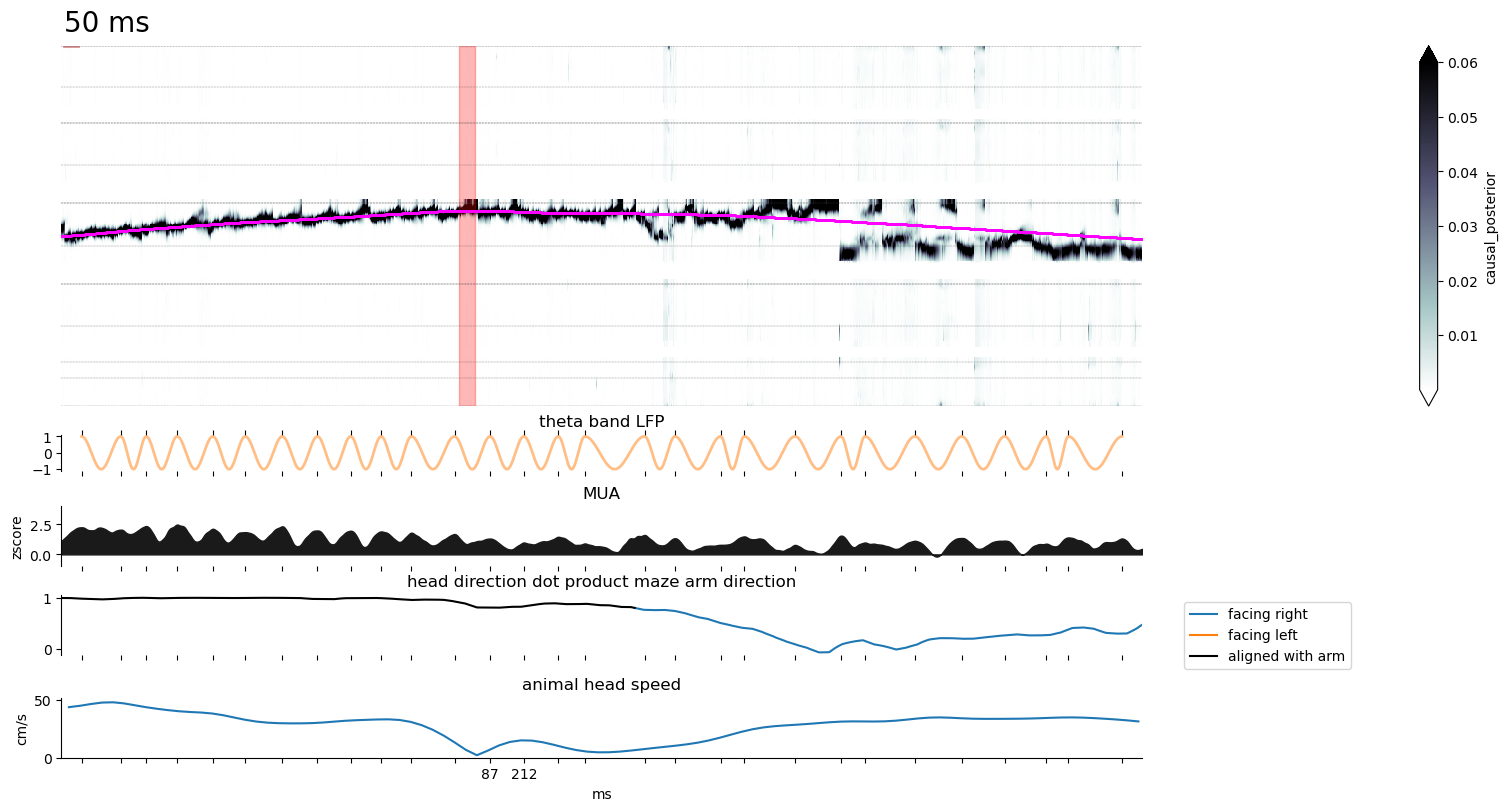

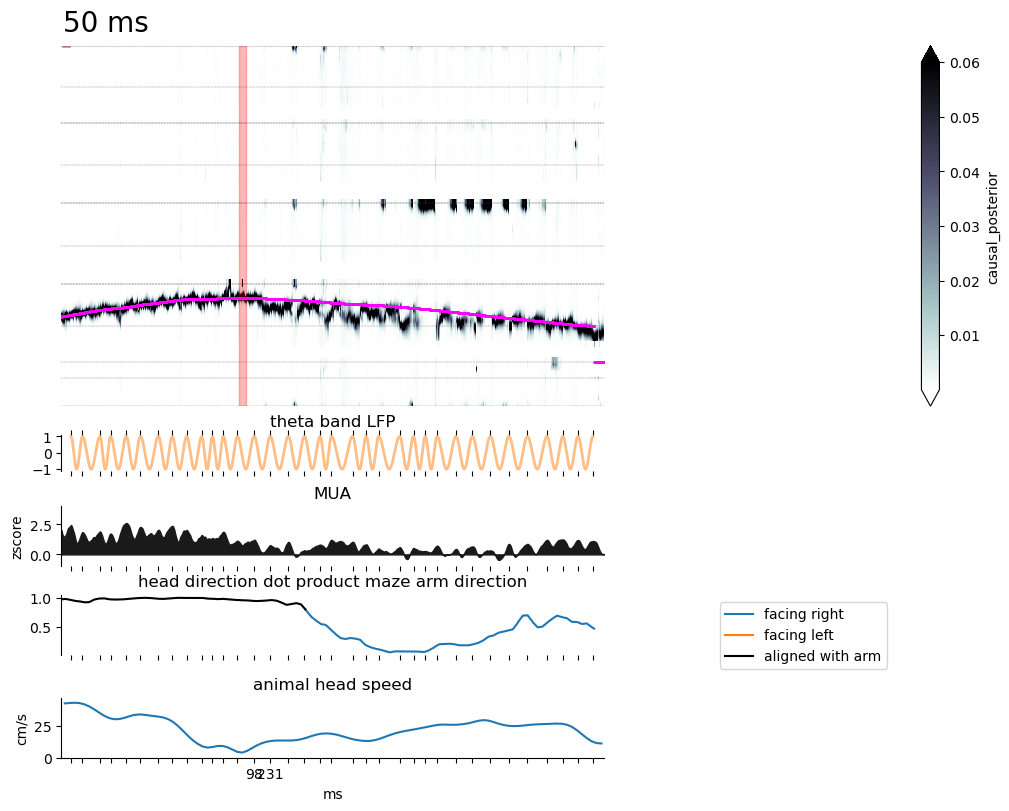

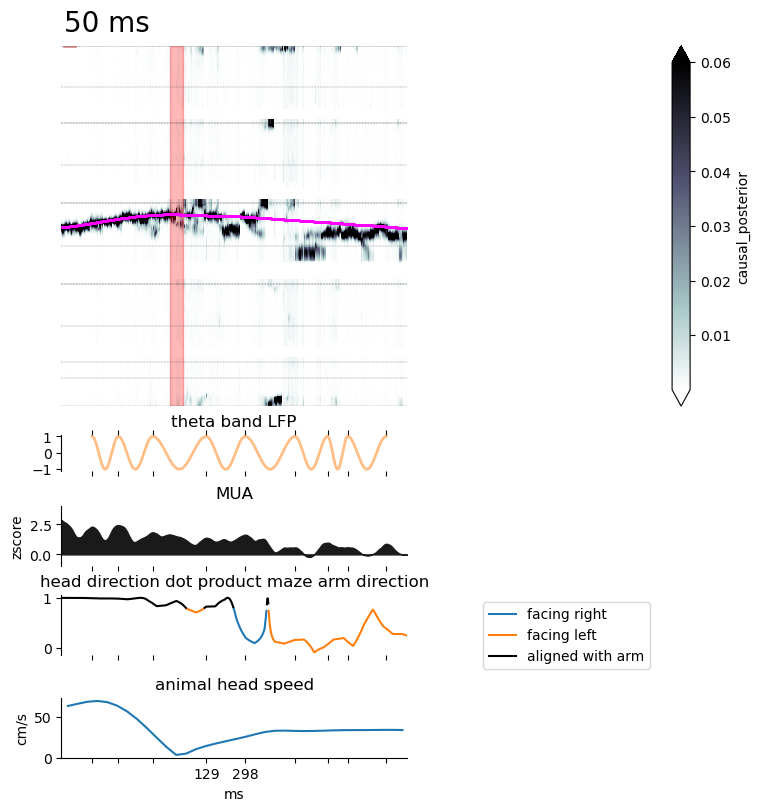

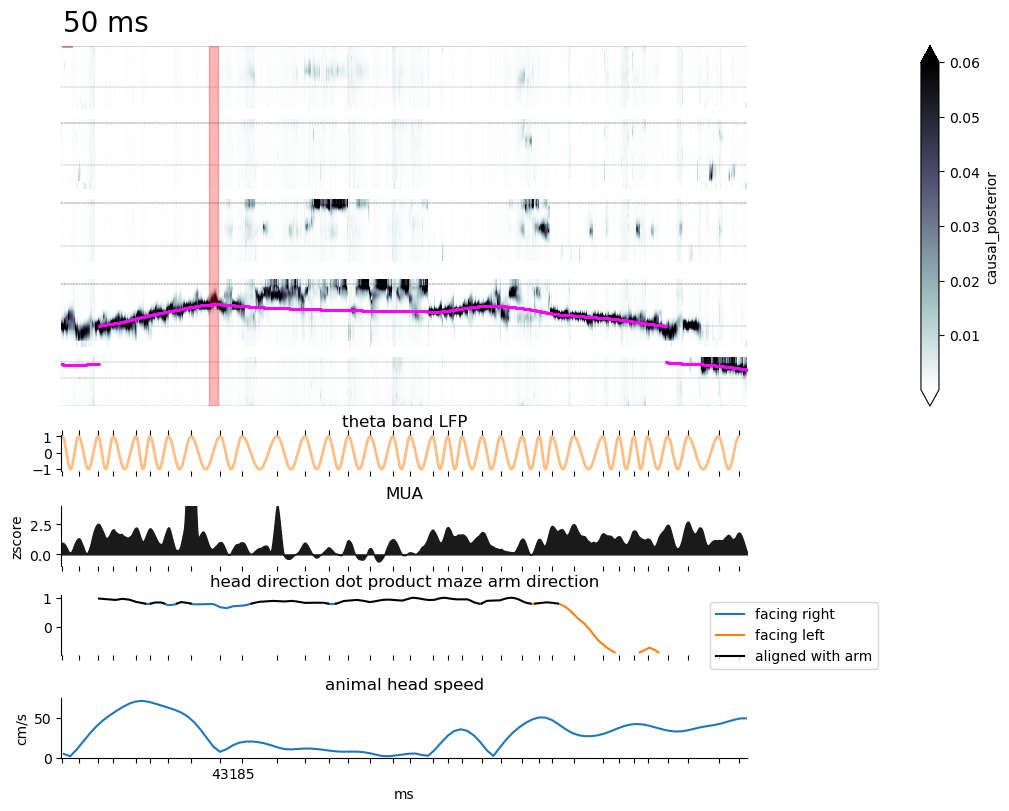

In [145]:
for example in examples_short:
    nwb_copy_file_name, epoch_num, session_name, t, ind, (tx, ty) = example
    animal = nwb_copy_file_name[:5]

    for param in params:
        variant = param["variant"]
        plot_data_filename = f"data_variant{variant}_{animal}_{nwb_copy_file_name}_{session_name}_trial{t}.pkl"

        try:
            output_path = os.path.join(output_folder,plot_data_filename)
            with open(output_path, 'rb') as file:
                data = pickle.load(file)
            print(f"Data loaded from {output_path}")
        except:
            continue

        mua_smoothened = smoothen_mua(data["mua_subset"]) # 20 ms window smoothened
        theta_from_mua = get_theta_from_mua(mua_smoothened)
        
        plot_decode_spiking(data["plottimes"],data["linear_position_subset"],data["decode"],theta_from_mua,
                        data["lfp_subset"], mua_smoothened, data["head_speed_subset"],
                        savefolder=data["output_folder"], savename=plot_data_filename,
                        t0 = data["t0"], plot_len = None,
                        turnaround = np.array([data["t0"]-0.03,data["t0"]+0.03]).reshape((1,-1)),likelihood = False,
                        rightward = data["rightward"],
                        head_direction = data["head_direction"], vmax = 0.06)

In [125]:
%debug

> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/changeOfMind_figures/example_snippet.py(290)plot_decode_spiking()
    288             for turn_ind in range(np.shape(turnaround)[0]):
    289                   for axes_id in [0,1,2,3]:
--> 290                         axes[axes_id].axvspan(turnaround[turn_ind][0], turnaround[turn_ind][1], color = "red", alpha = 0.1)
    291                         axes[axes_id].axvspan(turnaround[turn_ind][0], turnaround[turn_ind][1], color = "red", alpha = 0.1)
    292                         axes[axes_id].axvspan(turnaround[turn_ind][0], turnaround[turn_ind][1], color = "red", alpha = 0.1)



ipdb>  turnaround[turn_ind]


1704837198.252235


ipdb>  exit


#### longer snippets

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/longdata_variant2Dcausal2ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl


[14:44:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:44:04][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/longdata_variant1Dcausal2ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl


[14:44:06][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/longdata_variant1Dacausal2ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/longdata_variant1Dlikelihood40ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl


...

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/longdata_variant1Dacausal2ms_eliot_eliot20221021_.nwb_04_Seq2Session2_trial29.pkl


[14:44:34][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/longdata_variant1Dlikelihood40ms_eliot_eliot20221021_.nwb_04_Seq2Session2_trial29.pkl


[14:44:35][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/longdata_variant1Dlikelihood20ms_eliot_eliot20221021_.nwb_04_Seq2Session2_trial29.pkl


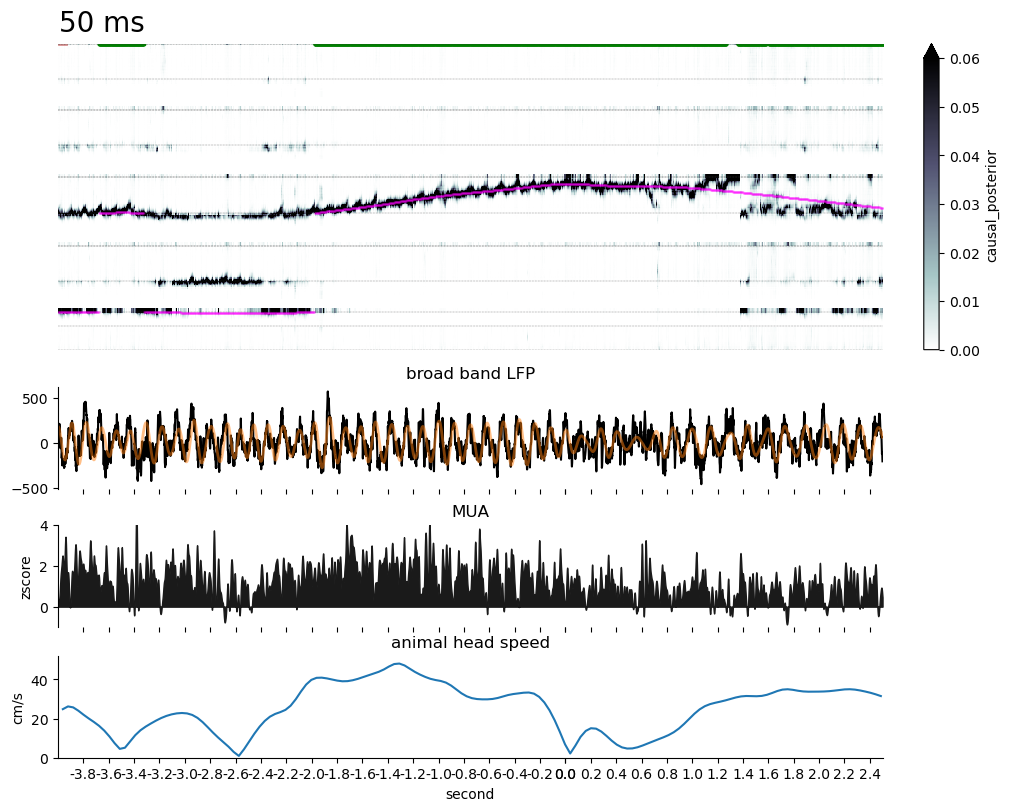

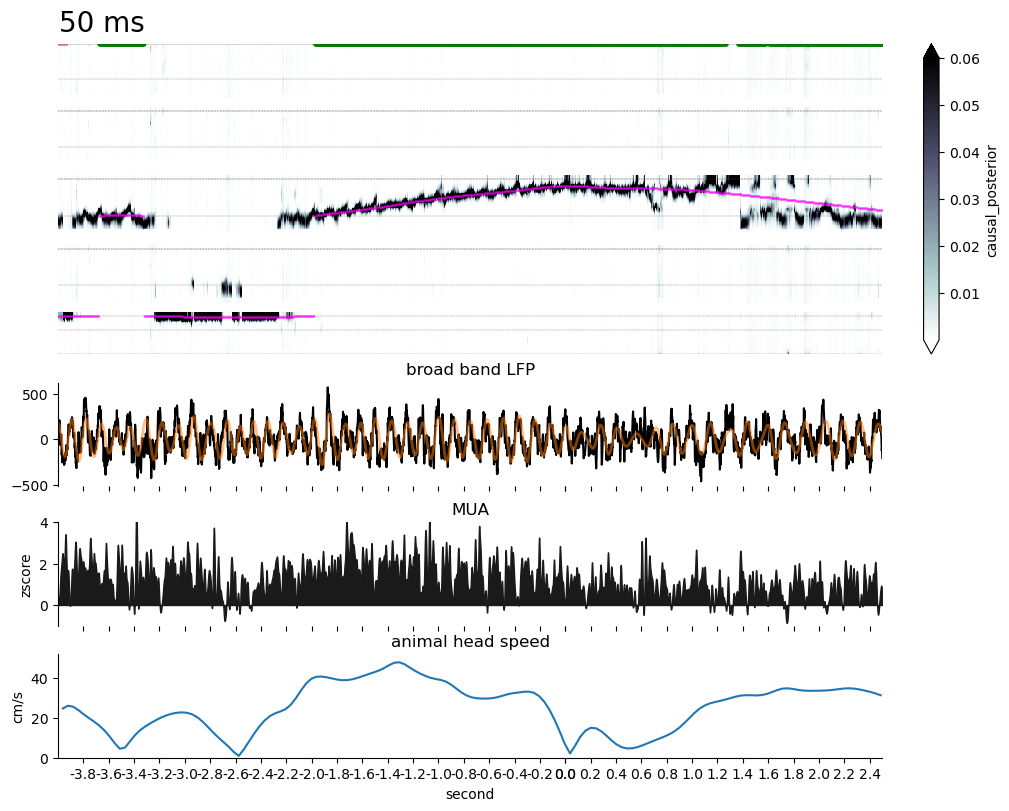

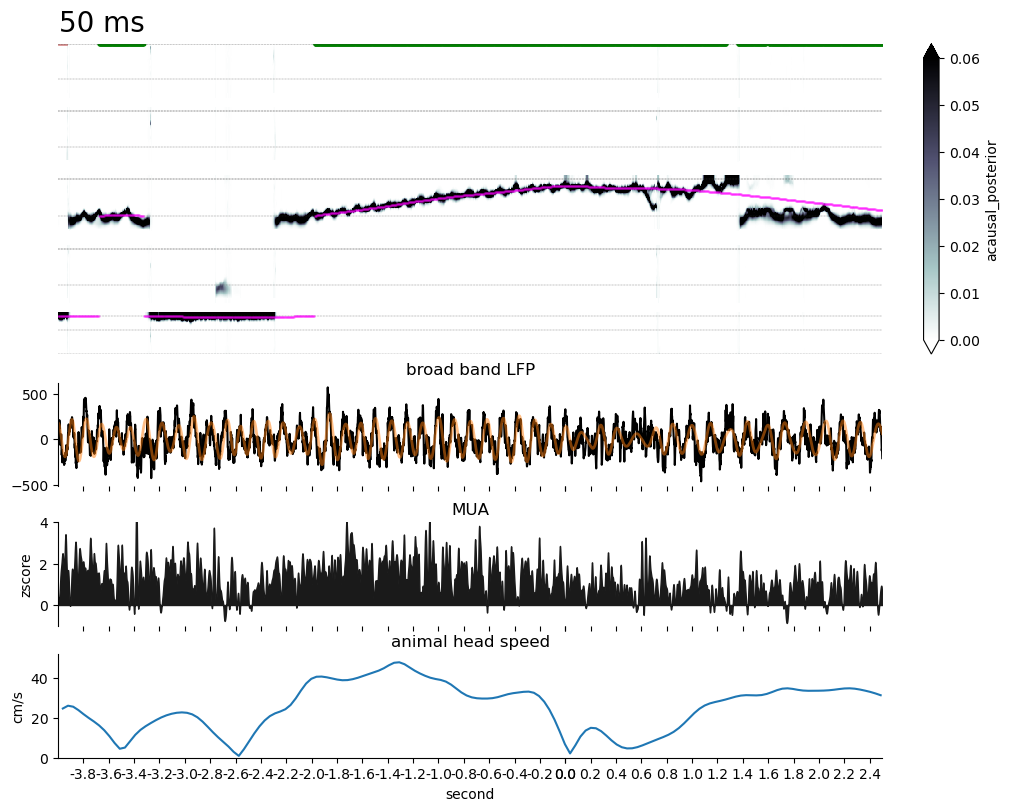

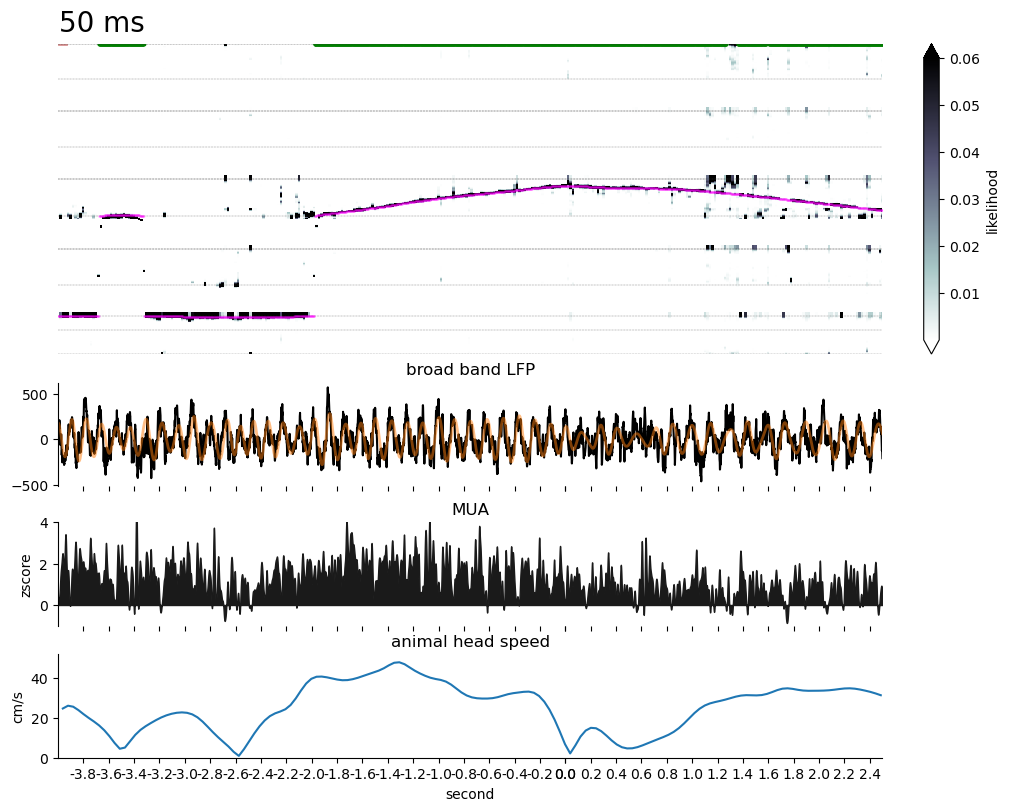

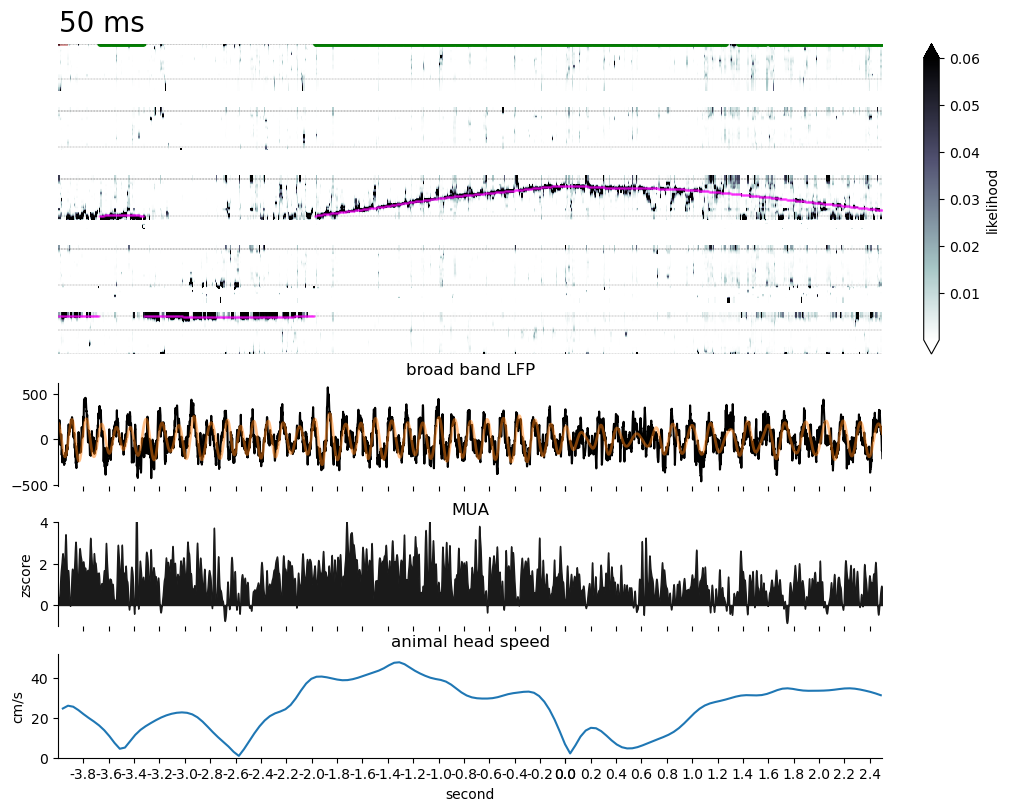

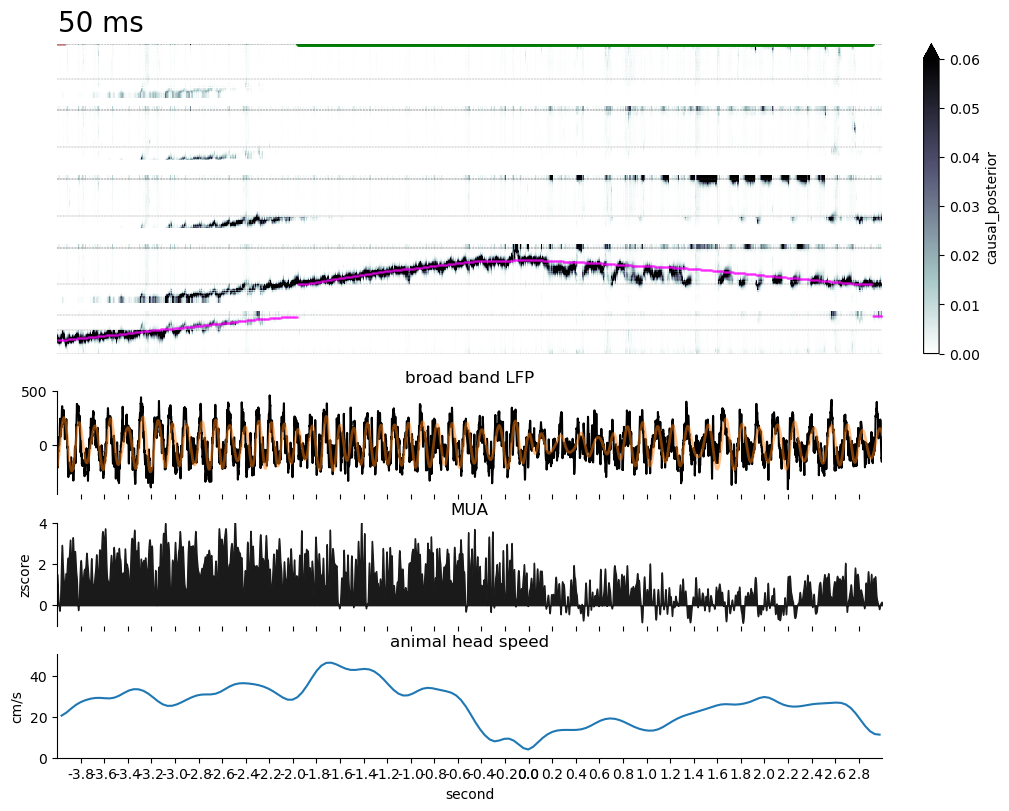

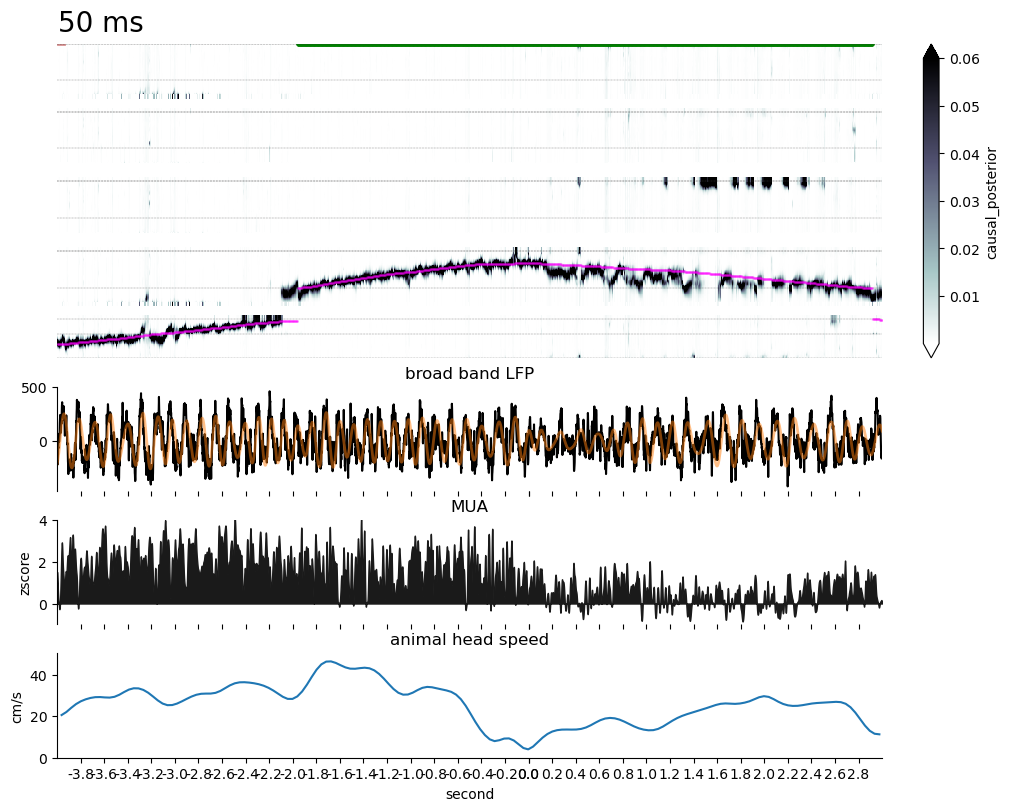

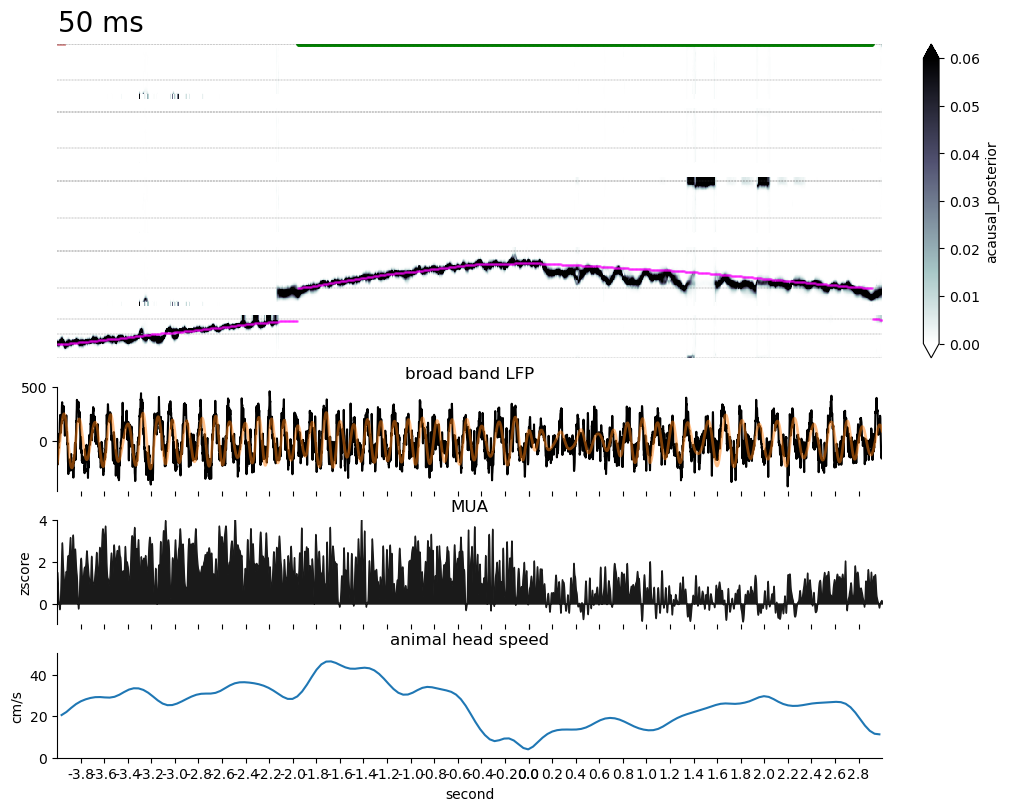

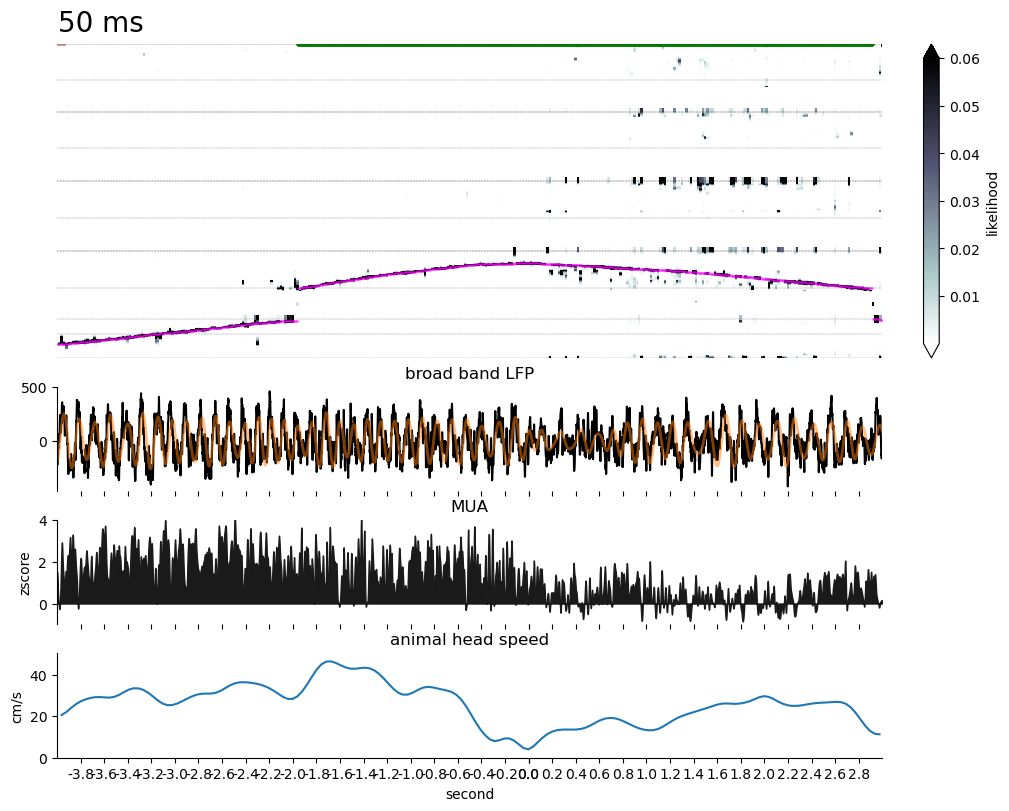

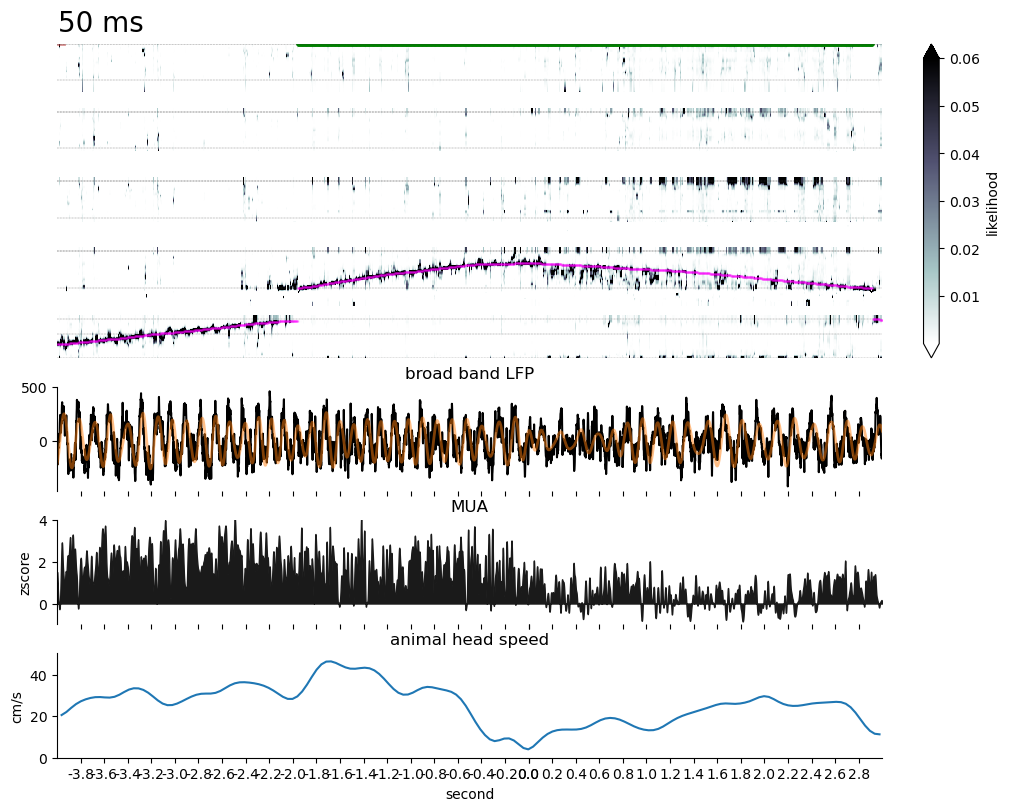

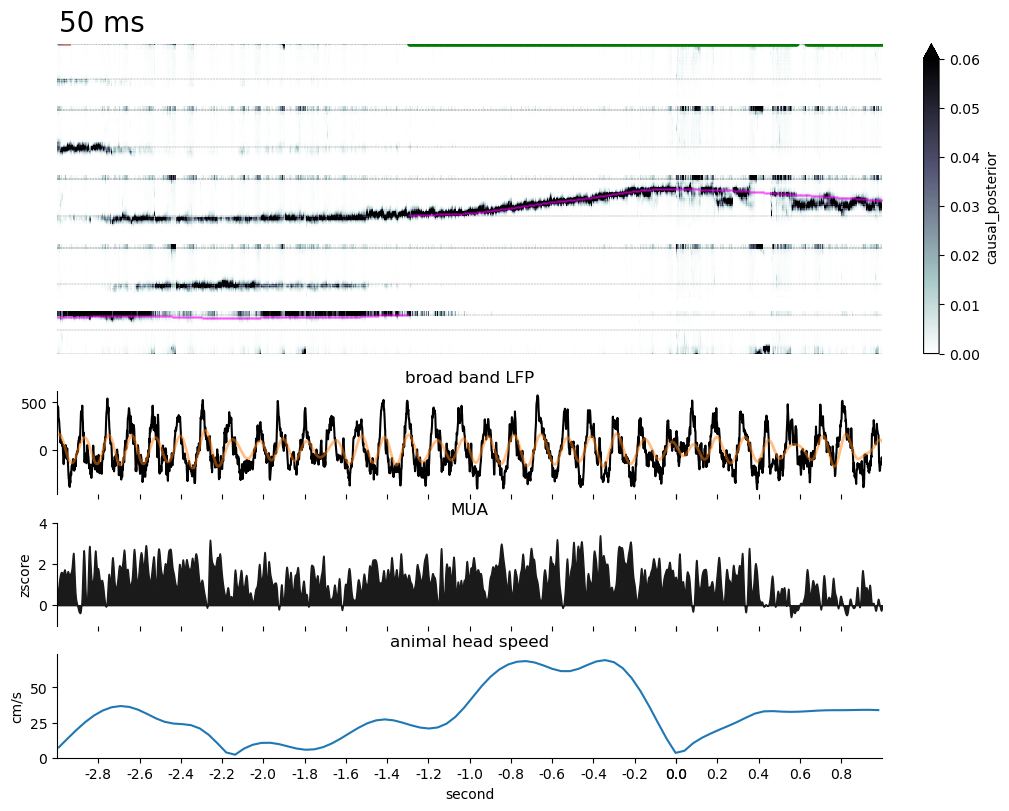

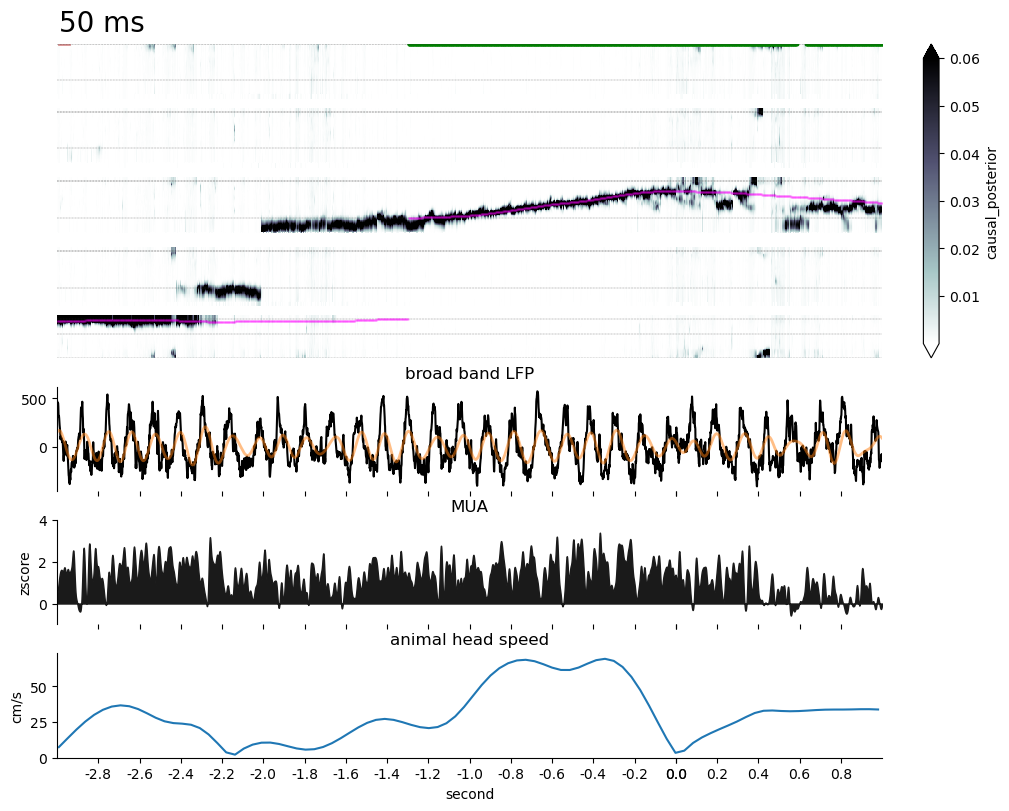

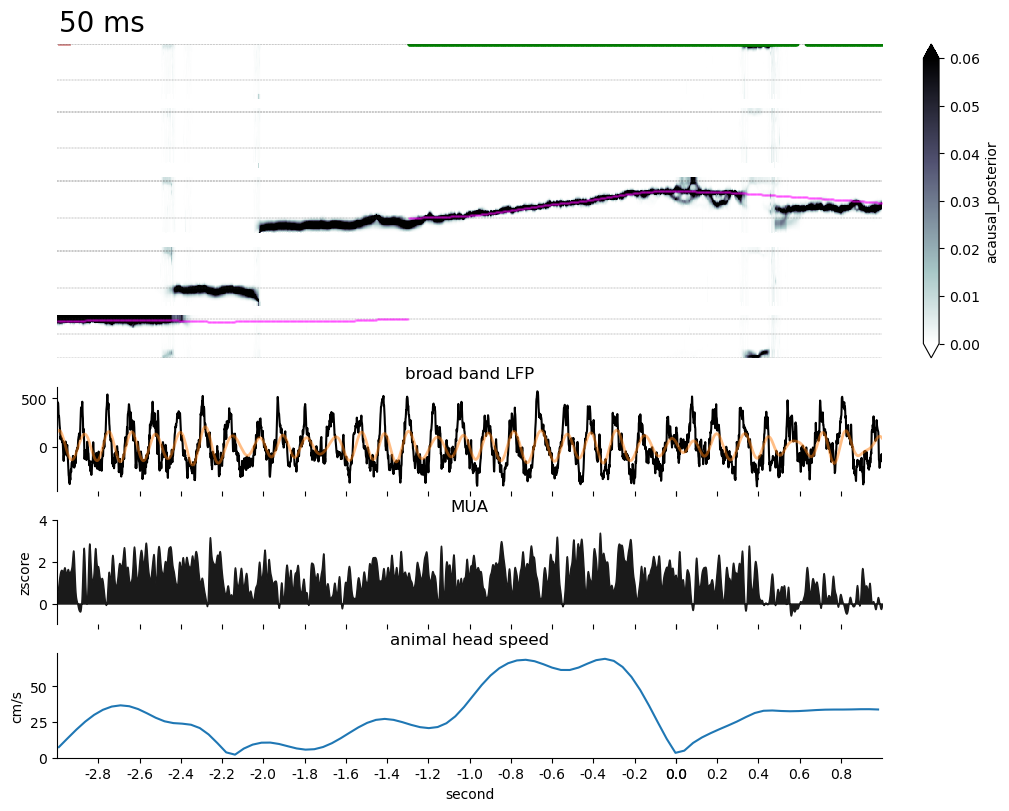

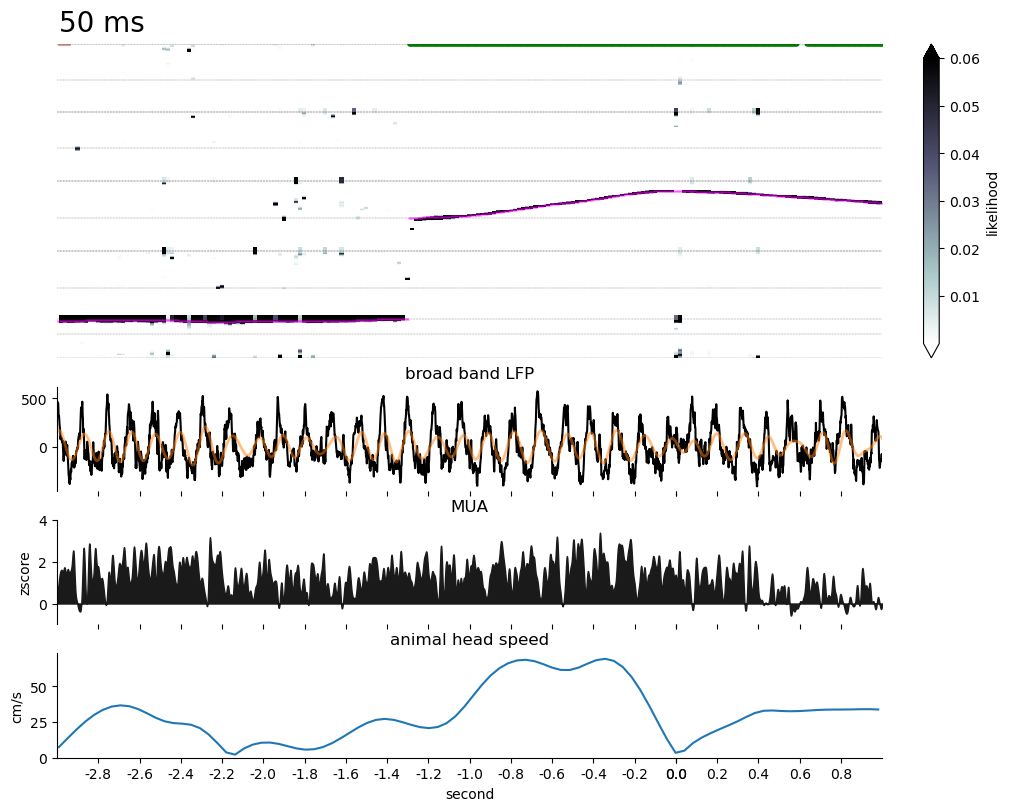

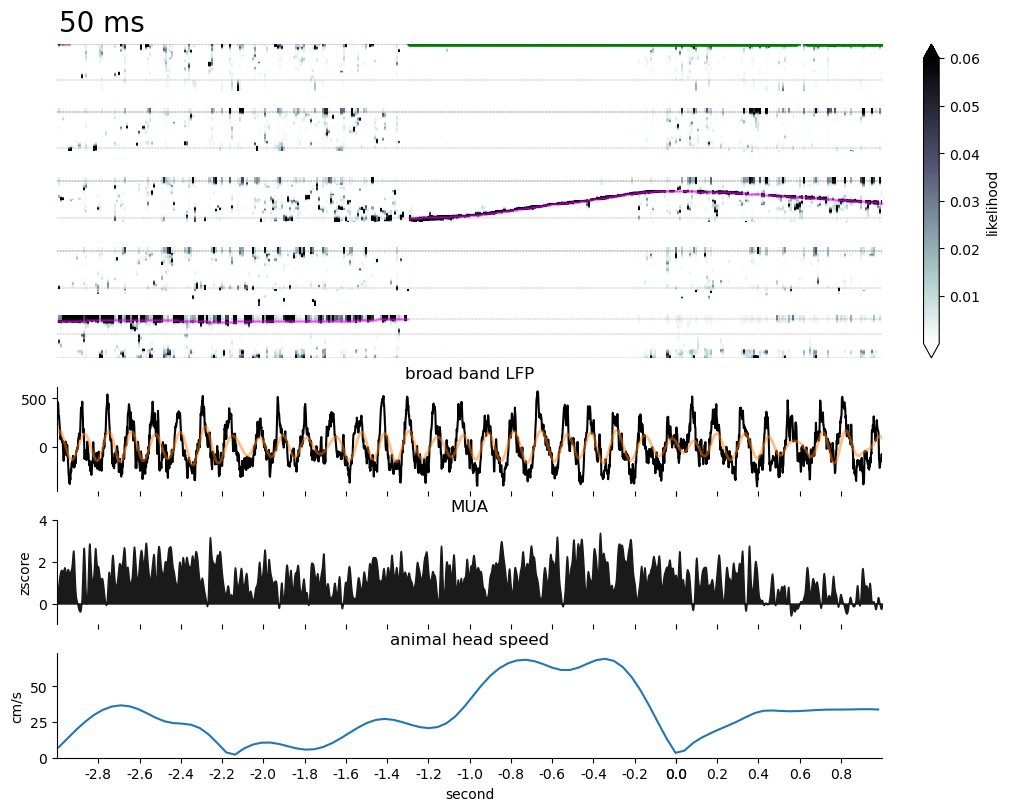

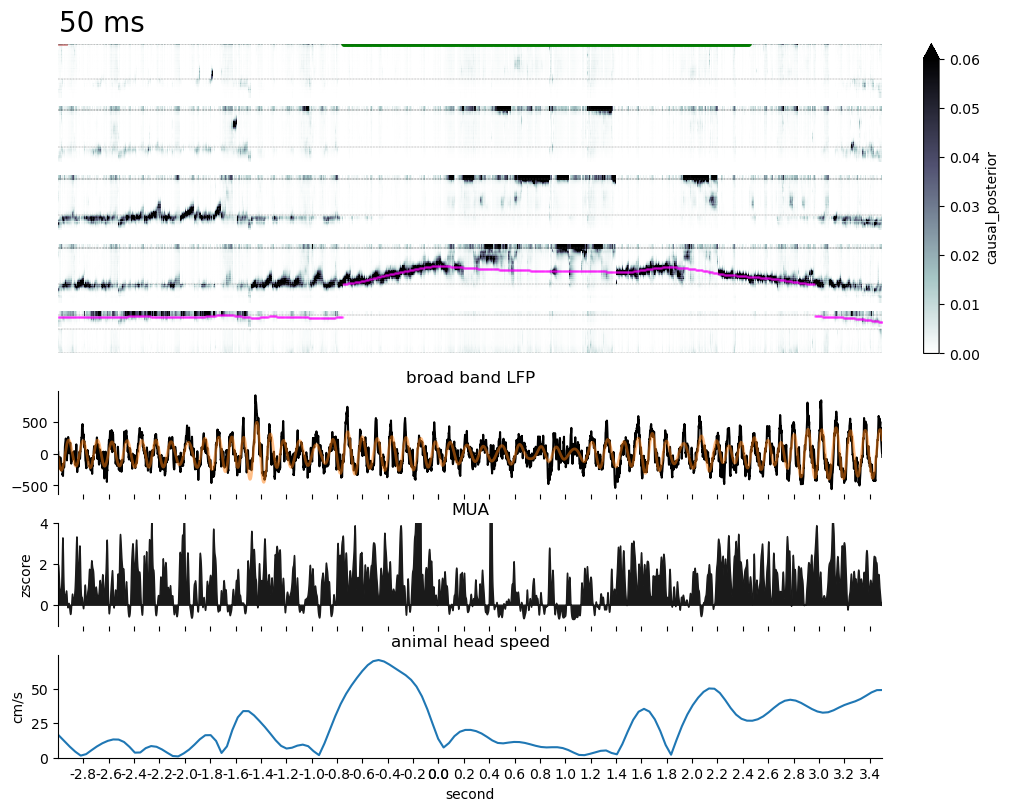

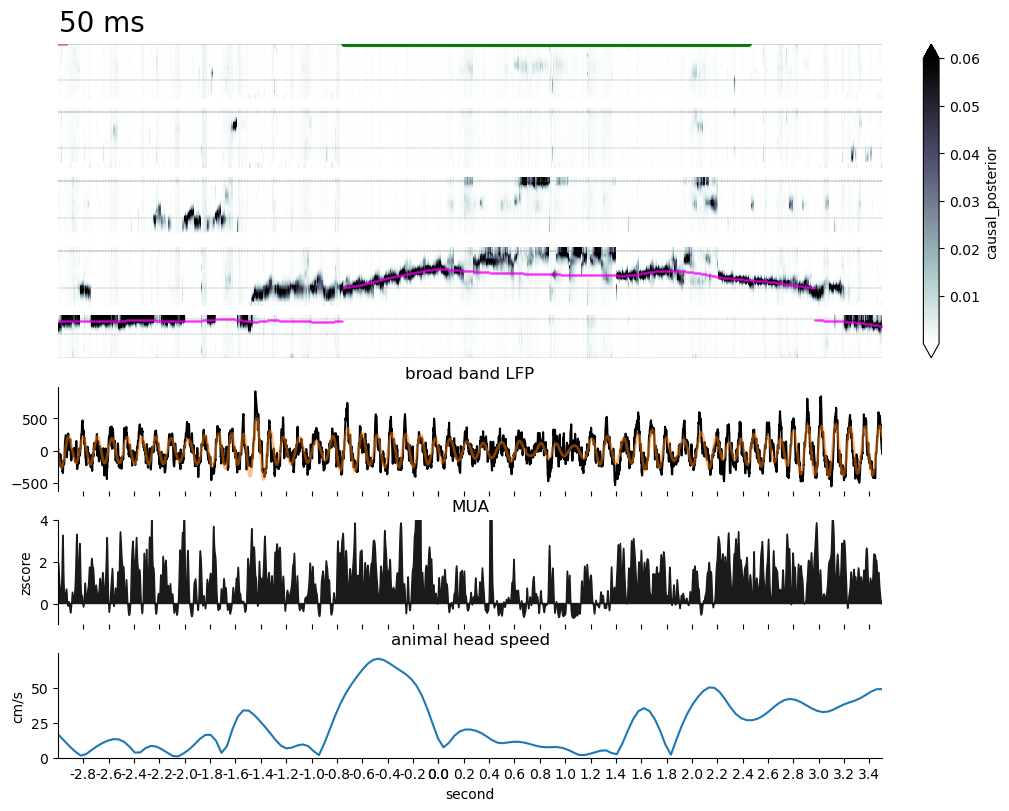

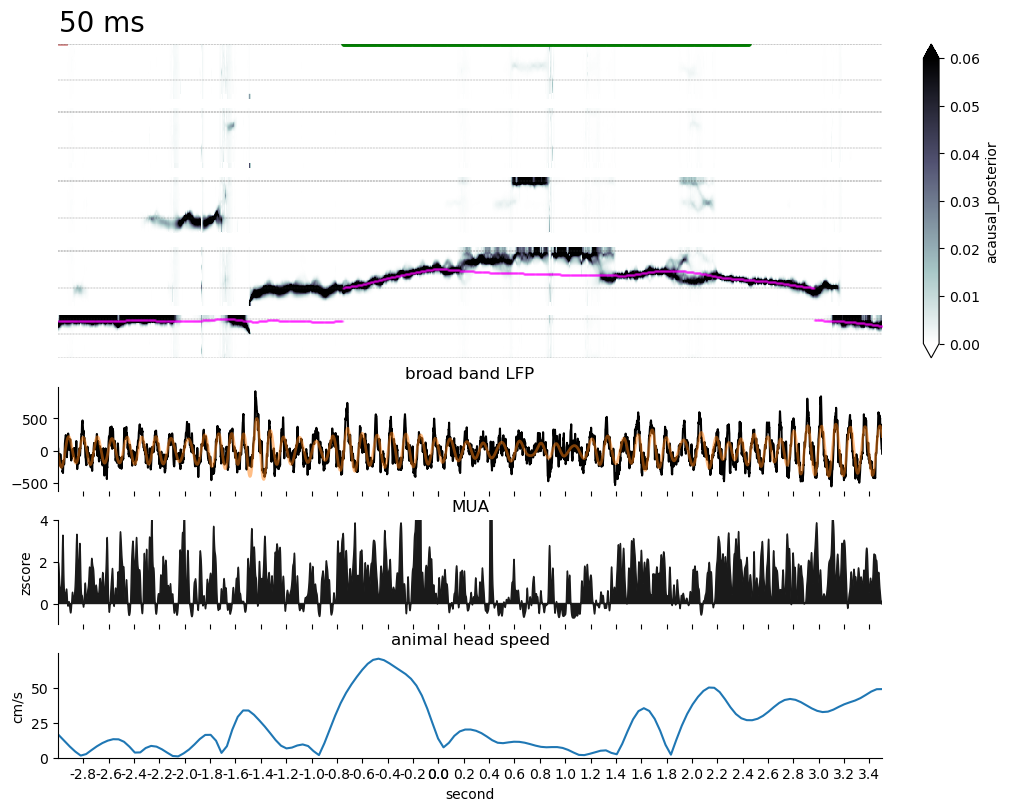

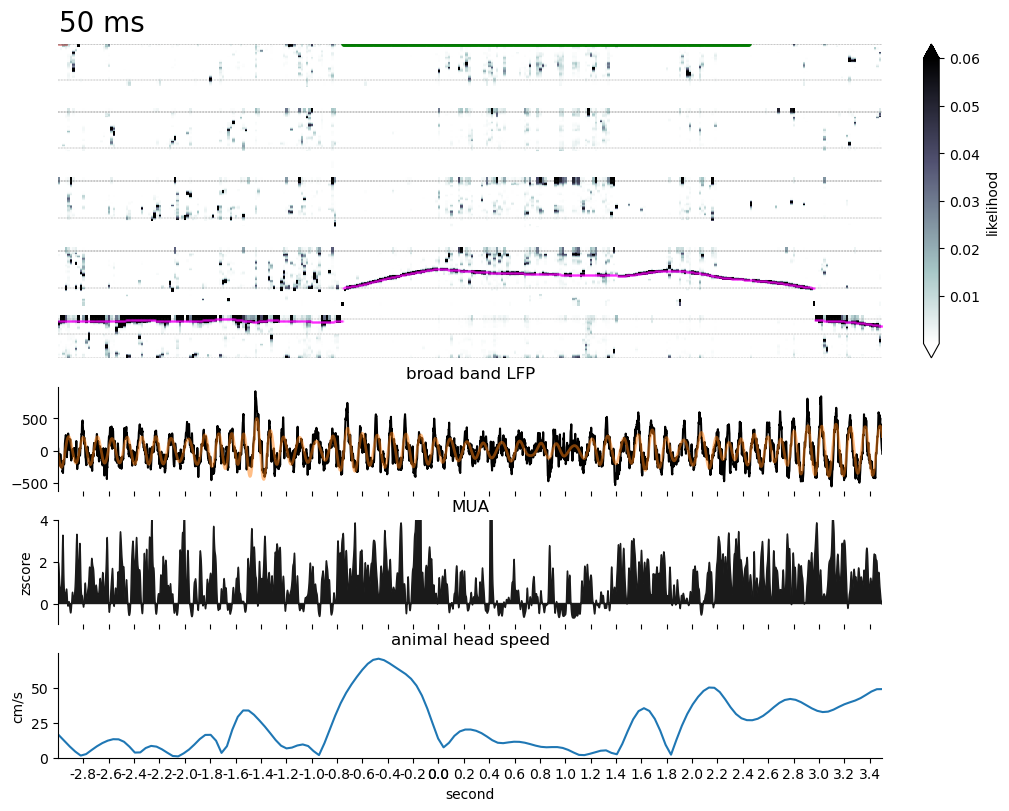

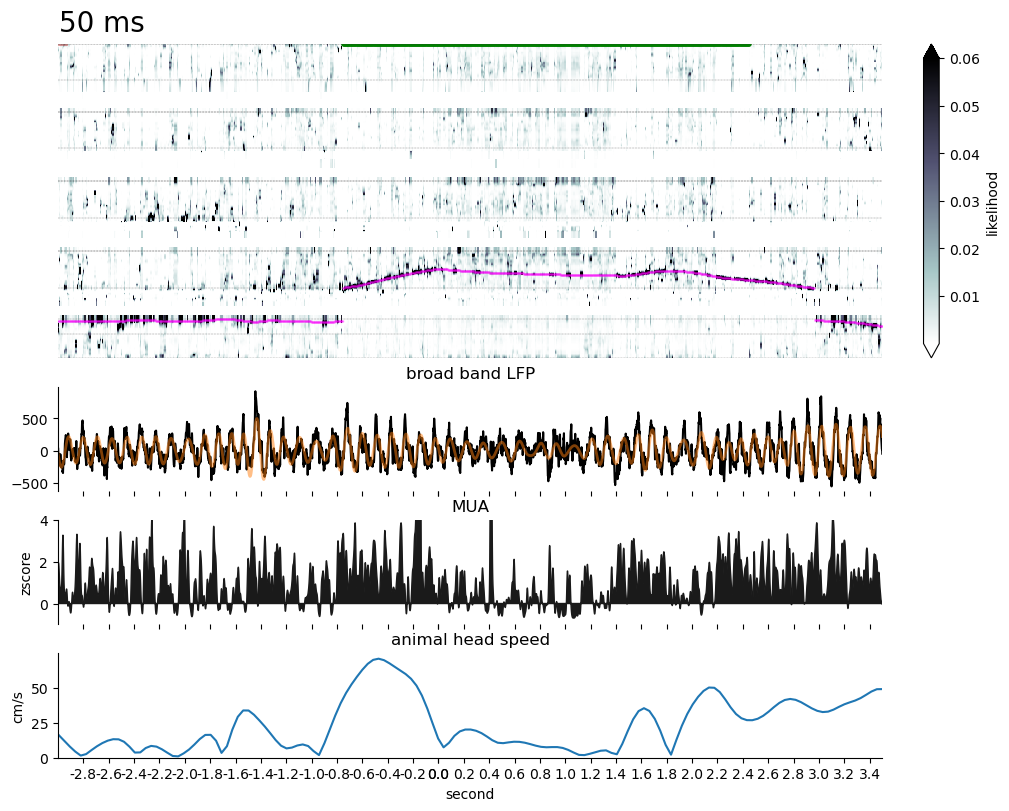

In [356]:
for example in examples_long:
    nwb_copy_file_name, epoch_num, session_name, t, ind, (tx, ty) = example
    animal = nwb_copy_file_name[:5]

    for param in params:
        variant = param["variant"]
        plot_data_filename = f"longdata_variant{variant}_{animal}_{nwb_copy_file_name}_{session_name}_trial{t}.pkl"

        output_path = os.path.join(output_folder,plot_data_filename)
        with open(output_path, 'rb') as file:
            data = pickle.load(file)
        print(f"Data loaded from {output_path}")
        
        plot_decode_spiking(data["plottimes"],data["linear_position_subset"],data["decode"],data["theta_subset"],
                        data["lfp_subset"], data["mua_subset"], data["head_speed_subset"],
                        savefolder=data["output_folder"], savename=plot_data_filename,
                        t0 = data["t0"], plot_len = 10,
                        turnaround = None,likelihood = likelihood,
                        head_direction_sign = data["head_direction_sign"], vmax = 0.06)